In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

DATA_DIR = "/kaggle/input/datasets/dhoogla/cicids2017"

PARQUET_FILES = [
    "Benign-Monday-no-metadata.parquet",
    "Botnet-Friday-no-metadata.parquet",
    "Bruteforce-Tuesday-no-metadata.parquet",
    "DDoS-Friday-no-metadata.parquet",
    "DoS-Wednesday-no-metadata.parquet",
    "Infiltration-Thursday-no-metadata.parquet",
    "Portscan-Friday-no-metadata.parquet",
    "WebAttacks-Thursday-no-metadata.parquet",
]

In [2]:
def infer_attack_category_from_filename(fname: str) -> str:
    base = os.path.basename(fname).lower()
    if "benign" in base:
        return "Normal"
    if "botnet" in base:
        return "Bot"
    if "bruteforce" in base:
        return "BruteForce"
    if "ddos" in base:
        return "DDoS"
    if "dos" in base:
        return "DoS"
    if "portscan" in base:
        return "PortScan"
    if "webattacks" in base or "webattacks" in base:
        return "WebAttack"
    if "infiltration" in base:
        return "Infiltration"
    return "Unknown"

dfs = []
for fname in PARQUET_FILES:
    fpath = os.path.join(DATA_DIR, fname)
    df_part = pd.read_parquet(fpath)
    df_part["attack_category"] = infer_attack_category_from_filename(fname)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,attack_category
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal


In [3]:
print("Shape (rows, columns):", df.shape)

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Approx. memory usage: {memory_mb:.2f} MB")

print("\nDataFrame info():")
df.info()

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe().T.head()

Shape (rows, columns): (2313810, 79)
Approx. memory usage: 793.32 MB

DataFrame info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313810 entries, 0 to 2313809
Data columns (total 79 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int32  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int32  
 4   Fwd Packets Length Total  int32  
 5   Bwd Packets Length Total  int32  
 6   Fwd Packet Length Max     int16  
 7   Fwd Packet Length Min     int16  
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     int16  
 11  Bwd Packet Length Min     int16  
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max  

,count,mean,std,min,25%,50%,75%,max
Protocol,2313810.0,1.050673e+01,5.416040e+00,0.0,6.0,6.0,17.00,17.0
Flow Duration,2313810.0,1.807575e+07,3.640823e+07,-13.0,476.0,64783.0,5856947.75,119999998.0
Total Fwd Packets,2313810.0,1.108391e+01,8.291879e+02,1.0,2.0,2.0,6.00,219759.0
Total Backward Packets,2313810.0,1.255334e+01,1.103179e+03,0.0,1.0,2.0,5.00,291922.0
Fwd Packets Length Total,2313810.0,6.664045e+02,1.105009e+04,0.0,37.0,74.0,356.00,12900000.0


In [4]:
EDA_SAMPLE_SIZE = 500_000
if len(df) > EDA_SAMPLE_SIZE:
    df_eda = df.sample(EDA_SAMPLE_SIZE, random_state=42)
else:
    df_eda = df.copy()

df_eda.shape

(500000, 79)

/tmp/ipykernel_23/4000374145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


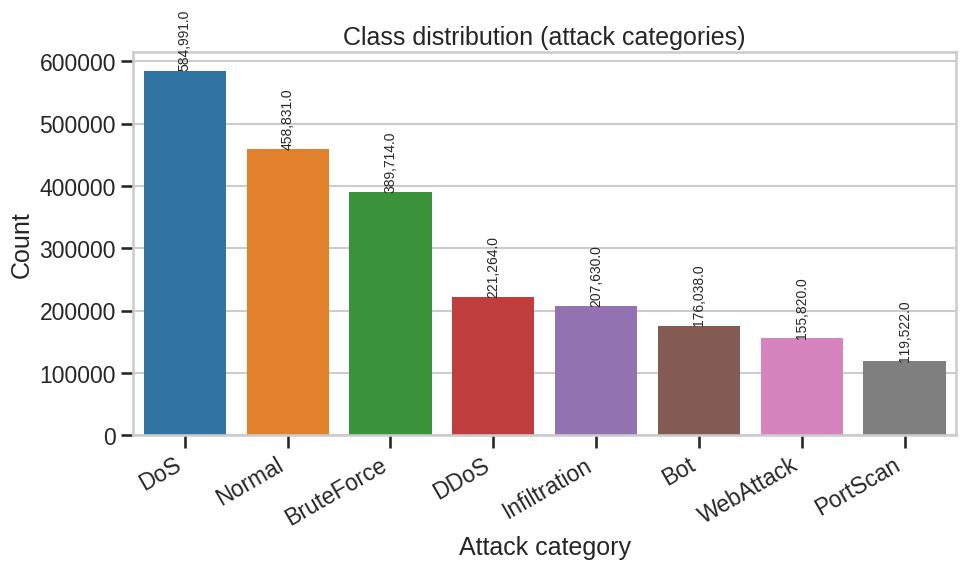

attack_category
DoS             25.28
Normal          19.83
BruteForce      16.84
DDoS             9.56
Infiltration     8.97
Bot              7.61
WebAttack        6.73
PortScan         5.17
Name: proportion, dtype: float64

In [5]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df,
    x="attack_category",
    order=df["attack_category"].value_counts().index,
    palette="tab10"
)

plt.title("Class distribution (attack categories)")
plt.xlabel("Attack category")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:,}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom", fontsize=10, rotation=90
    )

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

df["attack_category"].value_counts(normalize=True).mul(100).round(2)

In [6]:
# Use the EDA sample to keep things tractable
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns

corr_pearson = df_eda[numeric_cols].corr(method="pearson")
corr_spearman = df_eda[numeric_cols].corr(method="spearman")

corr_pearson.shape, corr_spearman.shape

((77, 77), (77, 77))

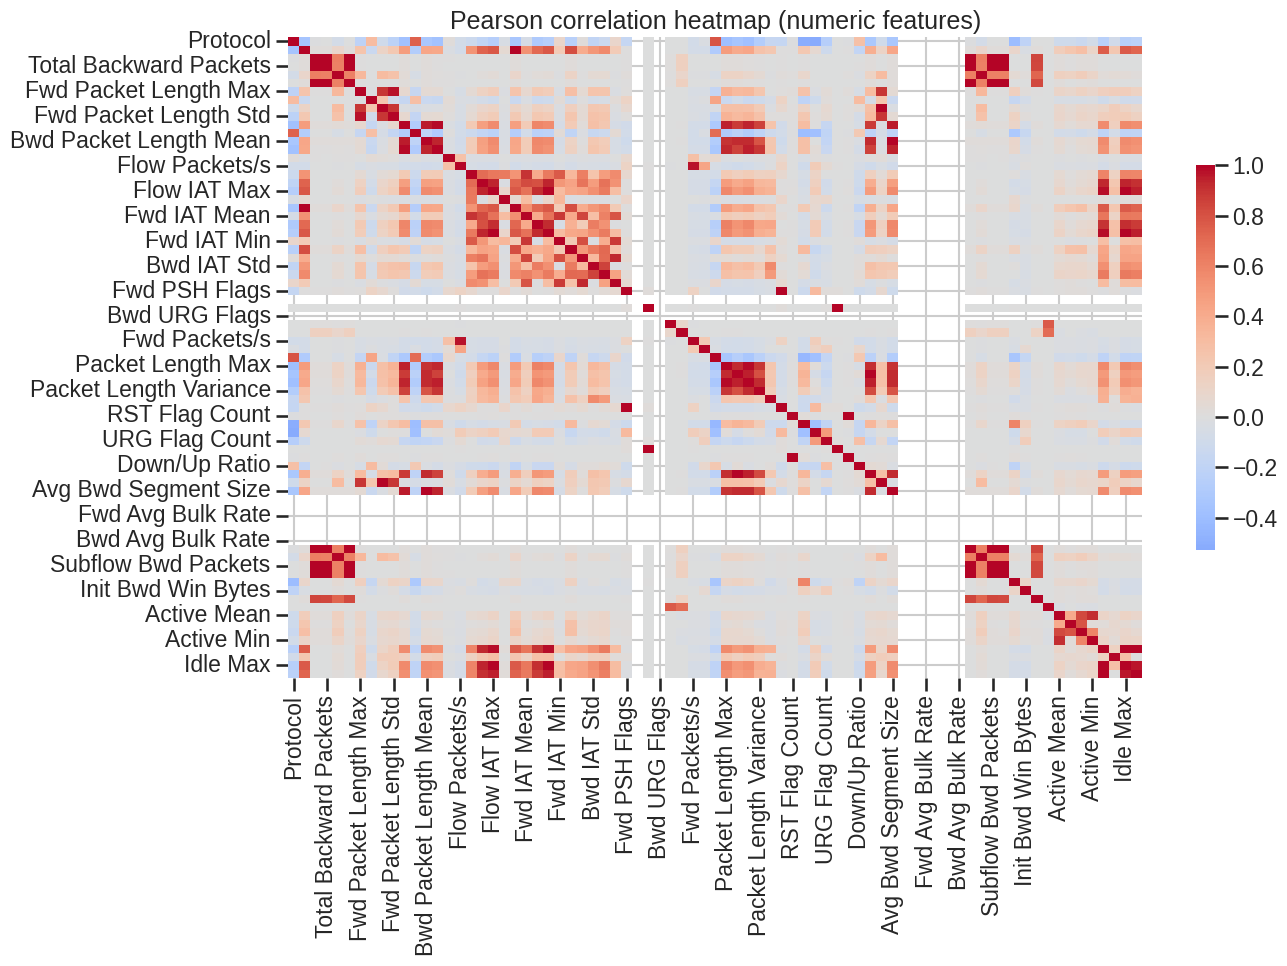

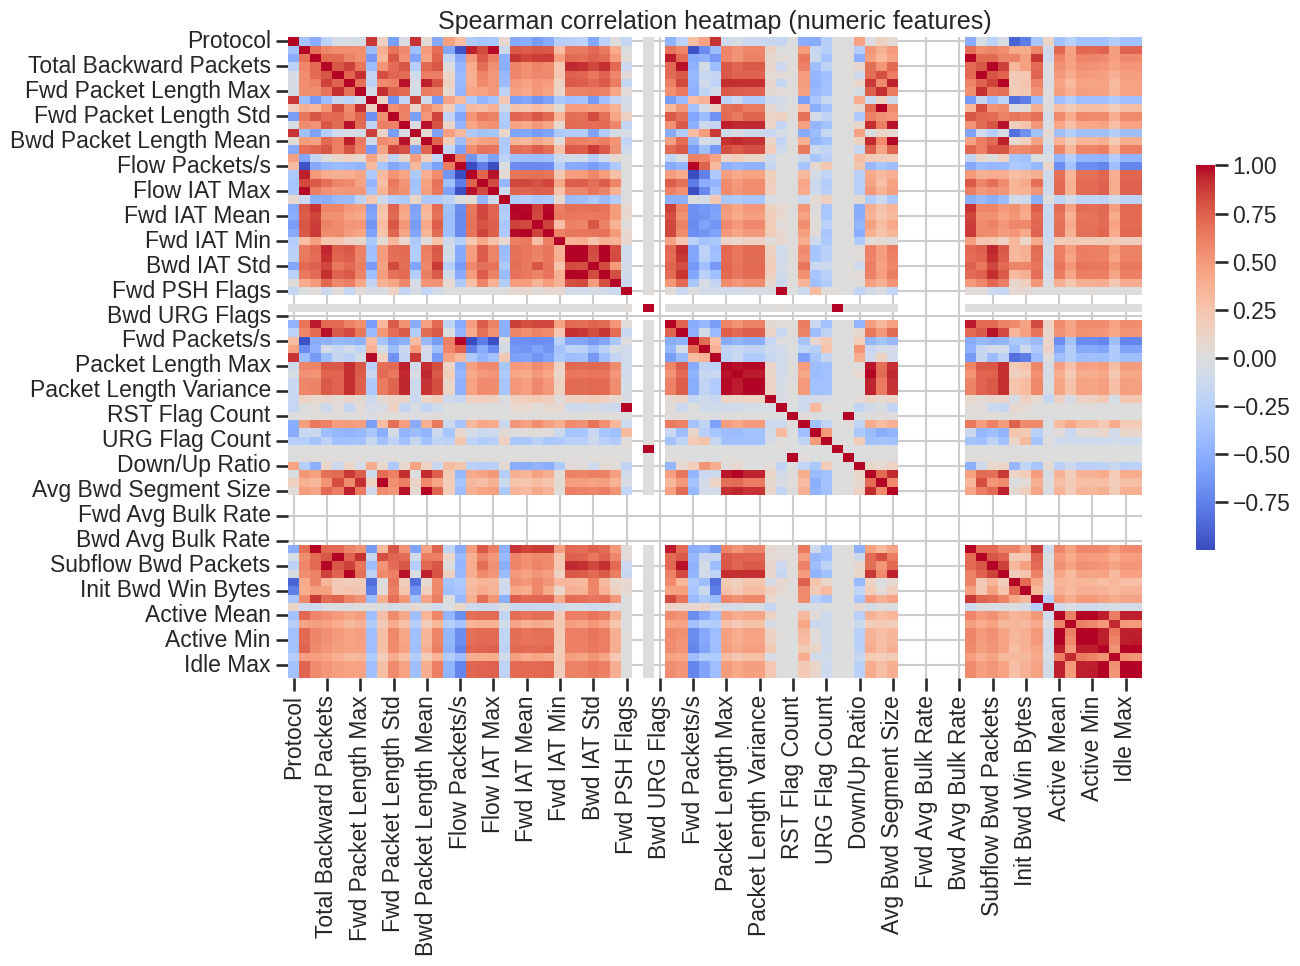

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_pearson,
    cmap="coolwarm",
    center=0,
    square=False,
    cbar_kws={"shrink": 0.6},
)
plt.title("Pearson correlation heatmap (numeric features)")
plt.tight_layout()
plt.savefig("correlation_heatmap_pearson.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_spearman,
    cmap="coolwarm",
    center=0,
    square=False,
    cbar_kws={"shrink": 0.6},
)
plt.title("Spearman correlation heatmap (numeric features)")
plt.tight_layout()
plt.savefig("correlation_heatmap_spearman.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

target_col = "attack_category"
X = df_eda[numeric_cols].fillna(0)
y = df_eda[target_col]

le = LabelEncoder()
y_enc = le.fit_transform(y)

mi_scores = mutual_info_classif(X, y_enc, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)

mi_series.head(20)

Avg Packet Size             0.367183
Packet Length Mean          0.335654
Packet Length Std           0.309300
Packet Length Variance      0.305668
Subflow Bwd Bytes           0.299034
Bwd Packets Length Total    0.297707
Avg Bwd Segment Size        0.292950
Bwd Packet Length Mean      0.291534
Subflow Fwd Bytes           0.289545
Fwd Packets Length Total    0.288558
Packet Length Max           0.285428
Fwd Packet Length Mean      0.271339
Fwd Packet Length Max       0.269651
Avg Fwd Segment Size        0.268848
Bwd Packet Length Std       0.261815
Flow IAT Max                0.256900
Fwd IAT Max                 0.249595
Bwd Packet Length Max       0.248526
Fwd Packet Length Std       0.248441
Fwd IAT Total               0.238935
dtype: float64

/tmp/ipykernel_23/3929939740.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


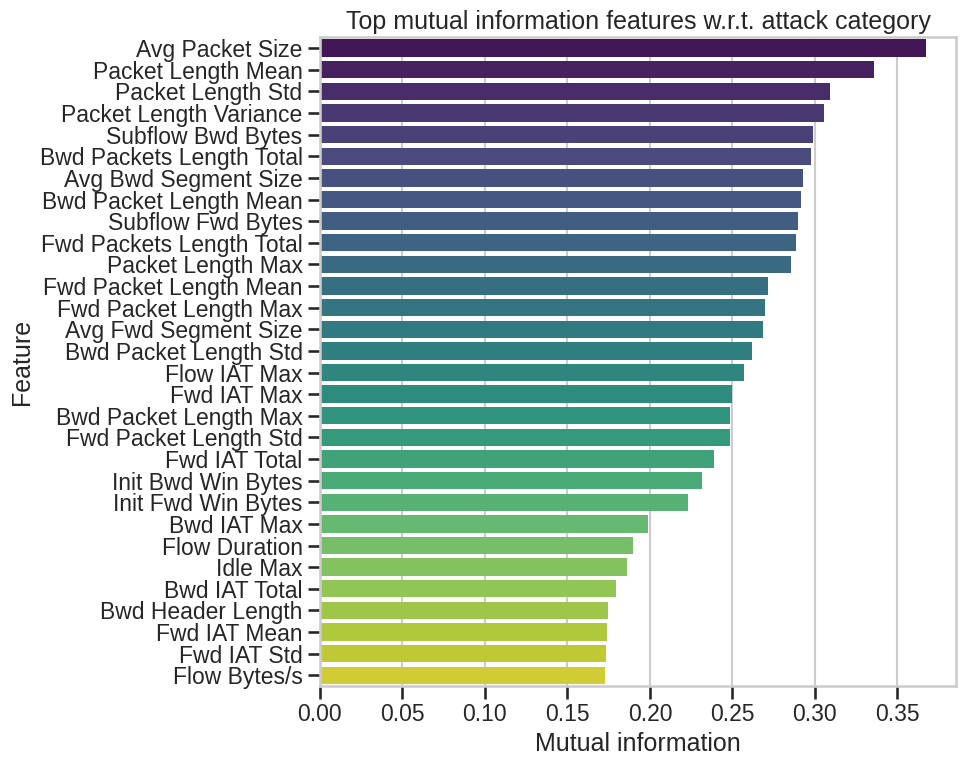

In [9]:
TOP_K_MI = 30

plt.figure(figsize=(10, 8))
sns.barplot(
    x=mi_series.head(TOP_K_MI),
    y=mi_series.head(TOP_K_MI).index,
    palette="viridis"
)
plt.title("Top mutual information features w.r.t. attack category")
plt.xlabel("Mutual information")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("mutual_information_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

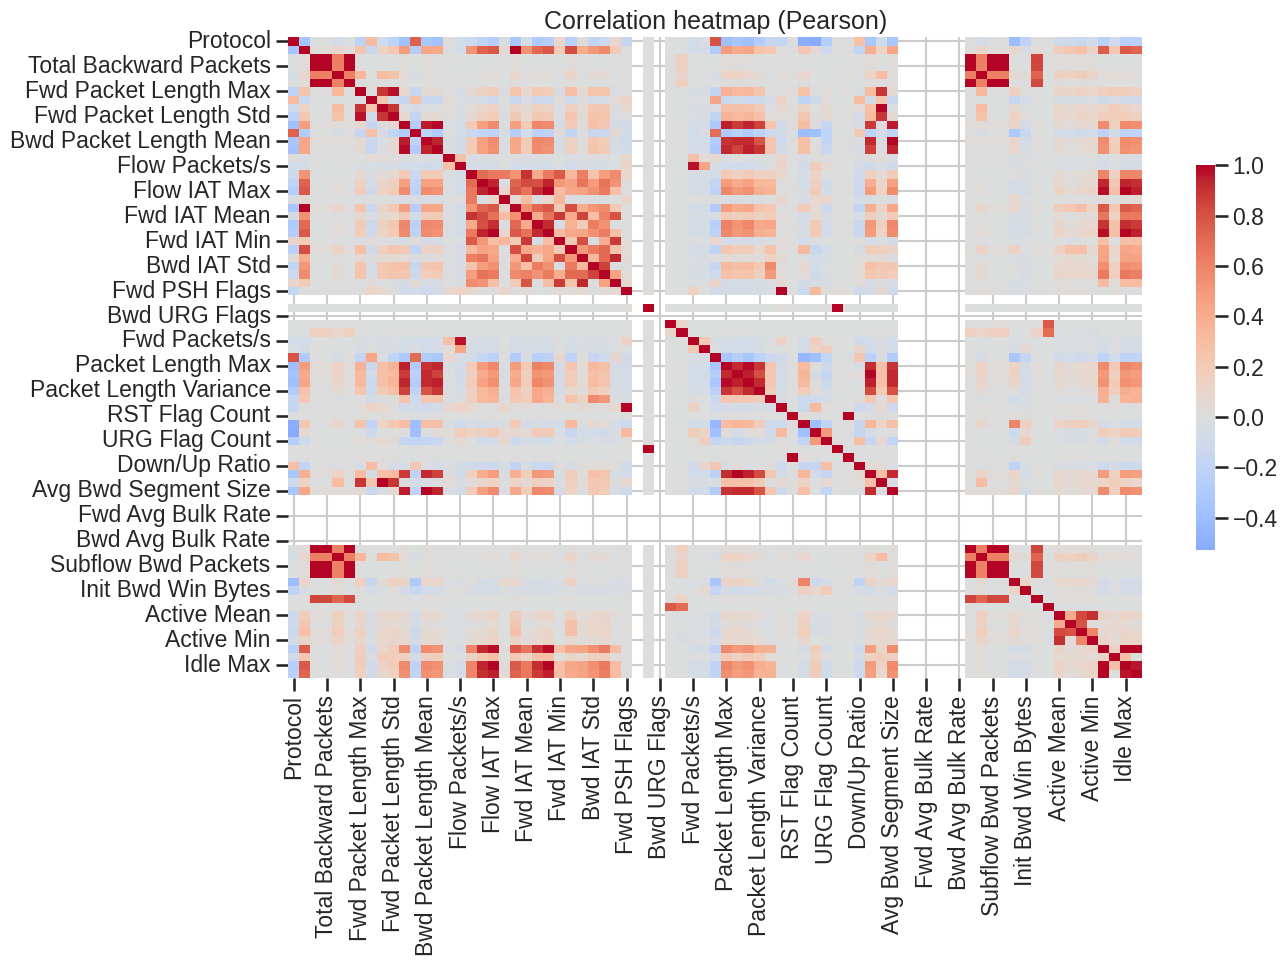

In [10]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_pearson,
    cmap="coolwarm",
    center=0,
    square=False,
    cbar_kws={"shrink": 0.6},
)
plt.title("Correlation heatmap (Pearson)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Replace these with the actual column names in your dataset
packet_len_cols = [c for c in df.columns if "Packet Length" in c or "Pkt Len" in c]
flow_duration_col = [c for c in df.columns if "Flow Duration" in c][0]
bytes_per_sec_col = [c for c in df.columns if "Flow Bytes/s" in c or "Bytes/s" in c][0]
pkts_per_sec_col = [c for c in df.columns if "Flow Packets/s" in c or "Pkts/s" in c][0]

packet_len_feature = packet_len_cols[0] if packet_len_cols else None
packet_len_feature

'Fwd Packet Length Max'

In [12]:
packet_len_feature = "Fwd Packet Length Max"  # matches your df columns
flow_duration_col = "Flow Duration"
bytes_per_sec_col = "Flow Bytes/s"
pkts_per_sec_col = "Flow Packets/s"

/tmp/ipykernel_23/1335532688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


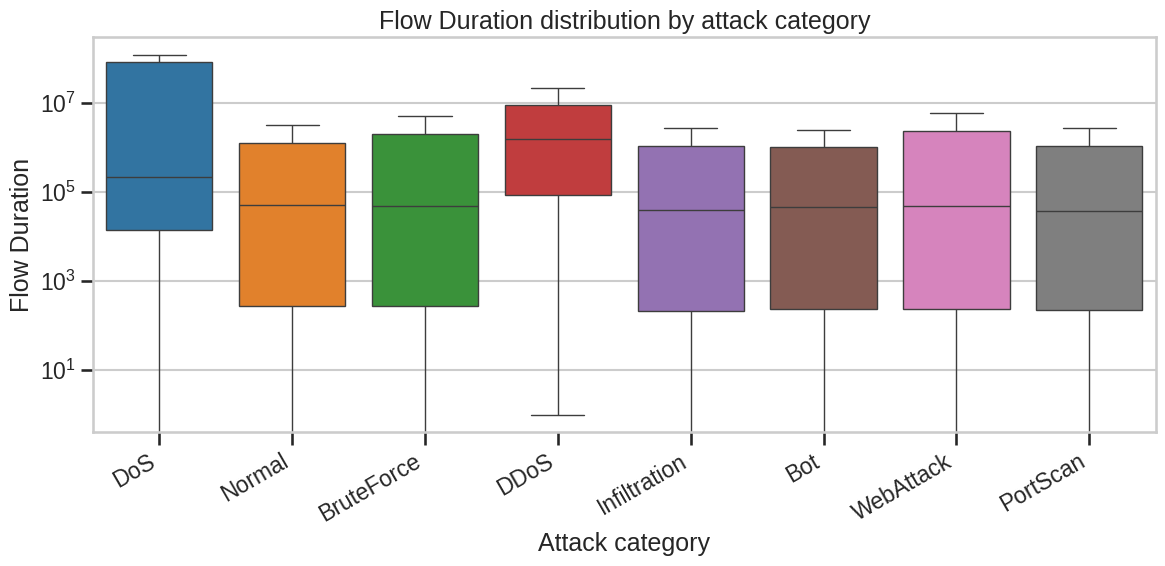

/tmp/ipykernel_23/1335532688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


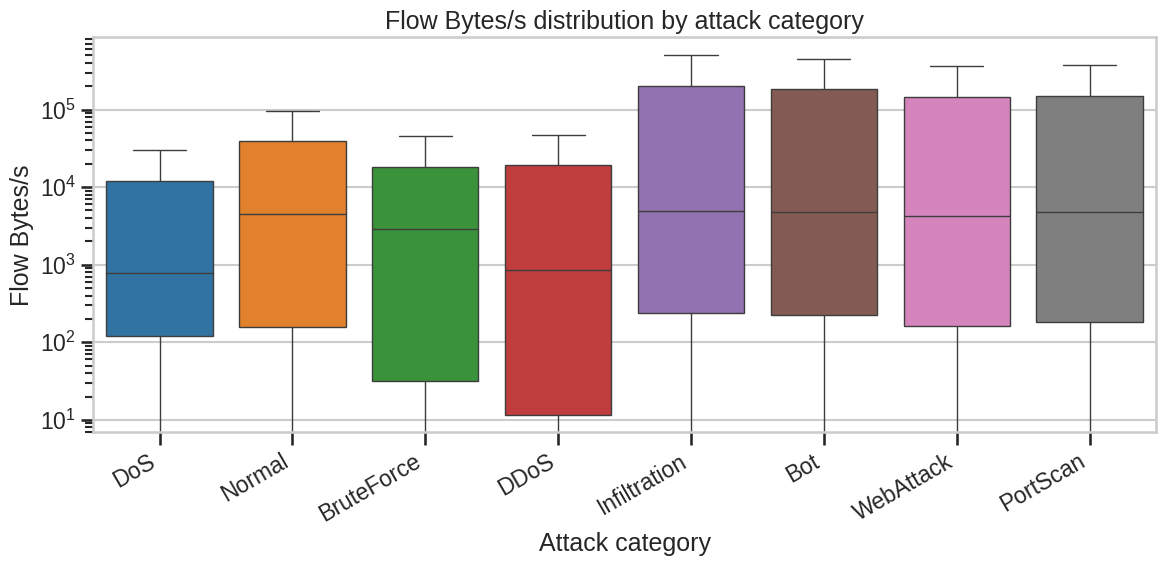

/tmp/ipykernel_23/1335532688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


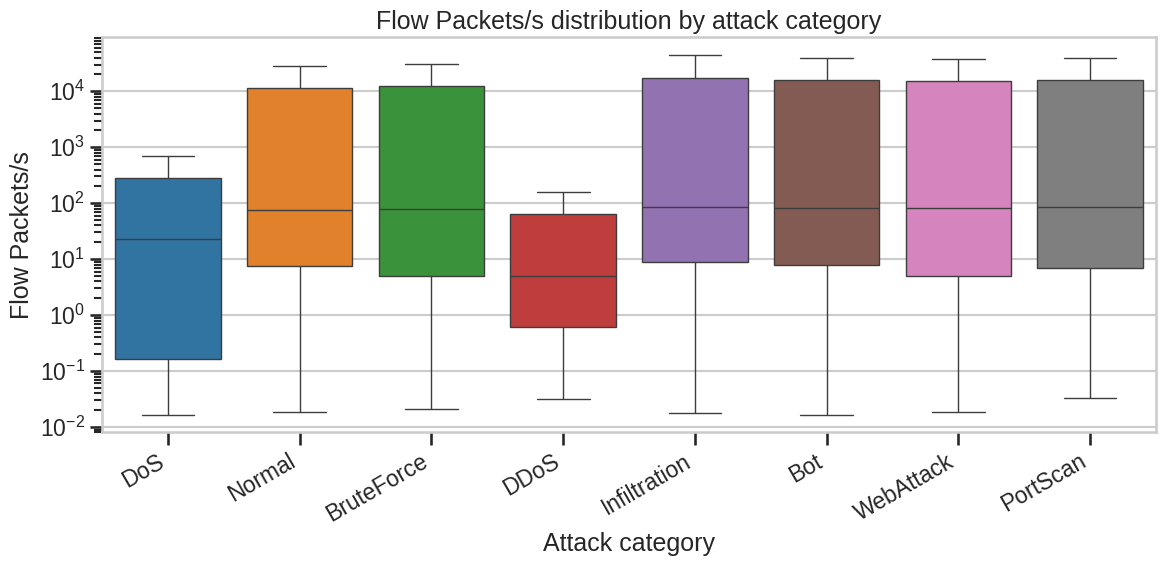

/tmp/ipykernel_23/1335532688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


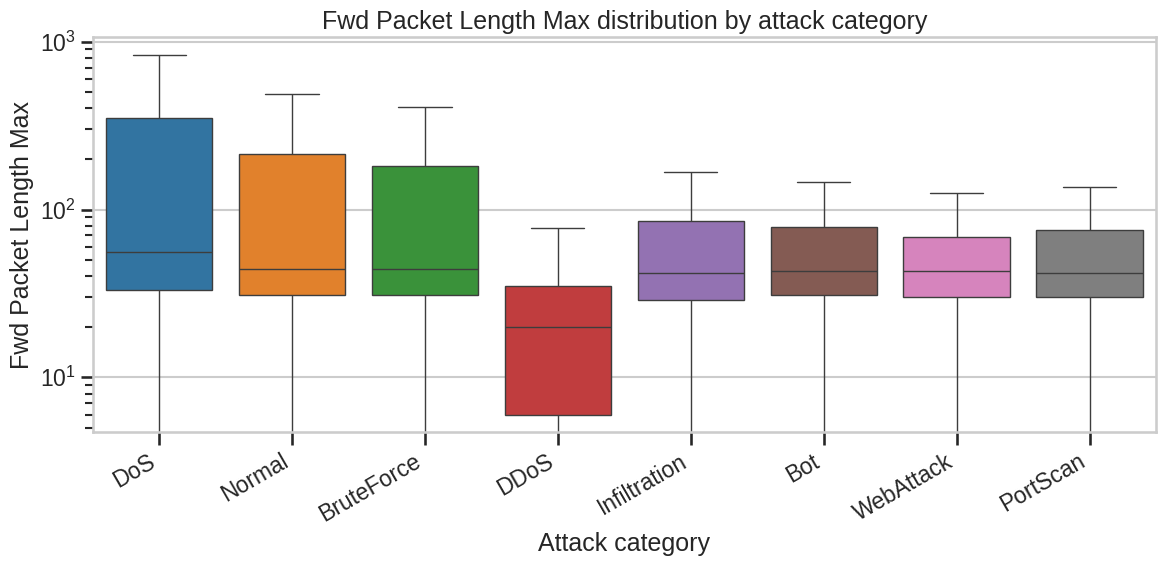

In [13]:
def plot_feature_by_attack(feature, log_scale=False, filename=None):
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(
        data=df_eda,
        x="attack_category",
        y=feature,
        order=df["attack_category"].value_counts().index,
        showfliers=False,
        palette="tab10"
    )
    plt.title(f"{feature} distribution by attack category")
    plt.xlabel("Attack category")
    plt.ylabel(feature)
    plt.xticks(rotation=30, ha="right")
    if log_scale:
        ax.set_yscale("log")
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_feature_by_attack(flow_duration_col, log_scale=True,
                       filename="flow_duration_by_attack.png")
plot_feature_by_attack(bytes_per_sec_col, log_scale=True,
                       filename="bytes_per_sec_by_attack.png")
plot_feature_by_attack(pkts_per_sec_col, log_scale=True,
                       filename="pkts_per_sec_by_attack.png")
if packet_len_feature is not None:
    plot_feature_by_attack(packet_len_feature, log_scale=True,
                           filename="packet_length_by_attack.png")

/tmp/ipykernel_23/277891416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_23/277891416.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


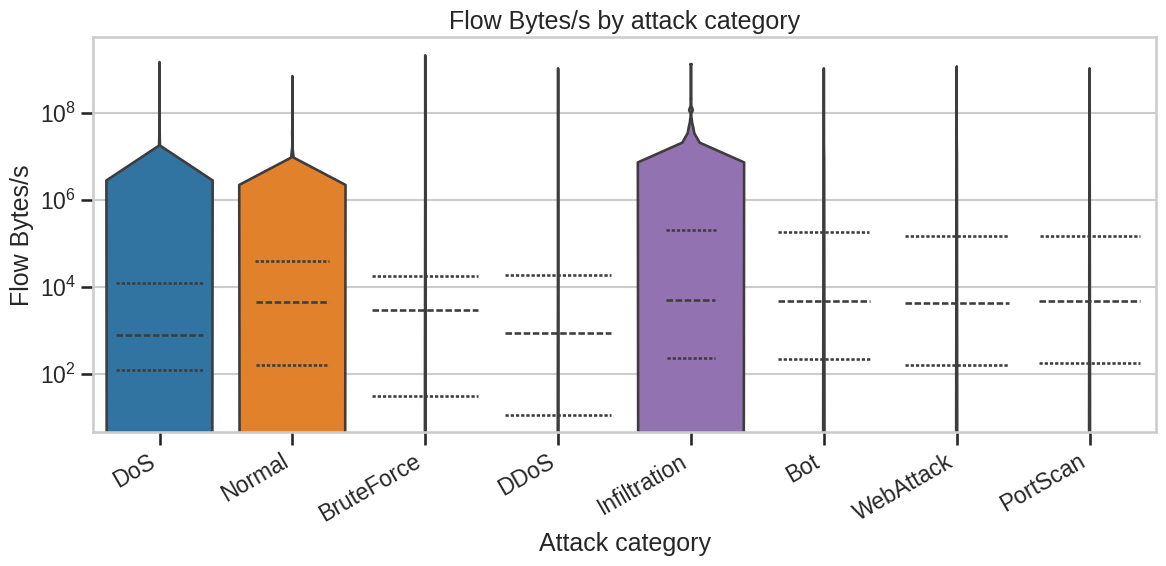

In [14]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_eda,
    x="attack_category",
    y=bytes_per_sec_col,
    order=df["attack_category"].value_counts().index,
    scale="width",
    cut=0,
    inner="quartile",
    palette="tab10"
)
plt.yscale("log")
plt.title(f"{bytes_per_sec_col} by attack category")
plt.xlabel("Attack category")
plt.ylabel(bytes_per_sec_col)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("bytes_per_sec_violin_by_attack.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Basic counts per category
counts = df["attack_category"].value_counts().rename("count")

# Per-category basic stats for a few core features
core_feats = [flow_duration_col, bytes_per_sec_col, pkts_per_sec_col]
if packet_len_feature is not None:
    core_feats.append(packet_len_feature)

agg_funcs = ["mean", "std", "median", "min", "max"]

stats_per_cat = (
    df.groupby("attack_category")[core_feats]
      .agg(agg_funcs)
)

# Flatten MultiIndex columns
stats_per_cat.columns = [
    f"{feat}_{stat}"
    for feat, stat in stats_per_cat.columns.to_flat_index()
]

eda_report = pd.concat([counts, stats_per_cat], axis=1).reset_index()
eda_report.rename(columns={"index": "attack_category"}, inplace=True)

eda_report.to_csv("eda_report.csv", index=False)
eda_report.head()

,attack_category,count,Flow Duration_mean,Flow Duration_std,Flow Duration_median,Flow Duration_min,Flow Duration_max,Flow Bytes/s_mean,Flow Bytes/s_std,Flow Bytes/s_median,...,Flow Packets/s_mean,Flow Packets/s_std,Flow Packets/s_median,Flow Packets/s_min,Flow Packets/s_max,Fwd Packet Length Max_mean,Fwd Packet Length Max_std,Fwd Packet Length Max_median,Fwd Packet Length Max_min,Fwd Packet Length Max_max
0,DoS,584991,3.315226e+07,4.466387e+07,216062.0,-1,119999998,412812.193589,7.589495e+06,774.424627,...,15846.745953,109090.231868,22.939158,-2000000.0,3000000.0,272.246122,646.560641,56.0,0,24820
1,Normal,458831,1.196980e+07,3.056838e+07,50968.0,-1,119999987,492449.247979,6.664948e+06,4514.529154,...,21747.182043,125255.355519,73.938520,-2000000.0,3000000.0,216.693811,475.822244,44.0,0,23360
2,BruteForce,389714,1.232761e+07,3.130788e+07,49430.0,-4,119999977,482478.800933,7.543503e+06,2941.357121,...,22310.082137,130734.588017,78.597043,-2000000.0,3000000.0,195.547881,500.252743,44.0,0,24820
3,DDoS,221264,1.657047e+07,3.175633e+07,1614921.5,-1,119999937,273228.014607,8.222828e+06,815.873290,...,8107.003398,82800.480694,4.883782,-2000000.0,3000000.0,548.650585,1881.396181,20.0,0,11680
4,Infiltration,207630,1.245150e+07,3.177389e+07,38832.5,-2,119999936,659966.101308,9.488594e+06,4940.857074,...,26388.513479,134200.821487,85.095520,-2000000.0,4000000.0,192.355156,502.471510,42.0,0,23360
